# Practical Session 2: Linear Programming for Power Control in Wireless Networks

This notebook translates the signal-to-interference constraints from the practical
script into linear inequalities in the power vector and then solves the resulting
optimization tasks.


In [1]:
# Import NumPy for linear algebra and array manipulations.
import numpy as np
# Import pandas to display tables of powers and feasibility results.
import pandas as pd
# Import cvxpy to formulate the linear programs.
import cvxpy as cp
# Import Matplotlib for feasibility plots.
import matplotlib.pyplot as plt

# Print vectors with compact formatting.
np.set_printoptions(precision=4, suppress=True)

# Prefer CLARABEL for the main solves and fall back to SCS when needed.
SOLVER = "CLARABEL" if "CLARABEL" in cp.installed_solvers() else "SCS"
# Fix the random seed for the random instance generator later in the notebook.
rng = np.random.default_rng(7)


## Problem data and linear model construction

Starting from the SINR condition, we rearrange each inequality so that the unknown
power vector appears only linearly.


In [2]:
# Channel gain matrix from the practical script.
G = np.array(
    [
        [1.0, 0.1, 0.2, 0.1],
        [0.2, 1.2, 0.1, 0.2],
        [0.1, 0.3, 1.1, 0.2],
        [0.2, 0.1, 0.2, 1.0],
    ],
    dtype=float,
)
# Positive receiver noise powers.
sigma = np.array([0.10, 0.10, 0.15, 0.10], dtype=float)
# Required SINR thresholds.
gamma = np.array([1.2, 1.0, 1.1, 0.9], dtype=float)


def build_linear_power_model(G, sigma, gamma):
    # Extract direct-link gains G_ii because they normalize the inequalities.
    direct_gains = np.diag(G)
    # Allocate the interference matrix F that collects off-diagonal effects.
    F = np.zeros_like(G)
    for i in range(G.shape[0]):
        for j in range(G.shape[1]):
            if i != j:
                # Store gamma_i * G_ij / G_ii in the off-diagonal entry.
                # TODO: Fill the off-diagonal interference matrix entry.
                F[i, j] = ...
    # Move the noise term to the right-hand side.
    u = gamma * sigma / direct_gains
    # The final linear system is (I - F) p >= u.
    # TODO: Build the final matrix A of the linear inequality system.
    A = ...
    return A, u, F


# Build the matrix inequality once for inspection and later reuse.
A, u, F = build_linear_power_model(G, sigma, gamma)
print("Matrix A in (I - F) p >= u:")
print(A)
print("Vector u:")
print(u)


Matrix A in (I - F) p >= u:
[[ 1.     -0.12   -0.24   -0.12  ]
 [-0.1667  1.     -0.0833 -0.1667]
 [-0.1    -0.3     1.     -0.2   ]
 [-0.18   -0.09   -0.18    1.    ]]
Vector u:
[0.12   0.0833 0.15   0.09  ]


## Task 2: Minimum total power

We solve the power minimization problem and verify that every achieved SINR meets the
required threshold numerically.


In [3]:
def achieved_sinr(G, sigma, p):
    # Compute the realized SINR of each user from a candidate power vector.
    sinr = np.zeros(G.shape[0])
    for i in range(G.shape[0]):
        # Interference is the received total power minus the desired signal term.
        interference = np.dot(G[i], p) - G[i, i] * p[i]
        sinr[i] = G[i, i] * p[i] / (interference + sigma[i])
    return sinr


def safe_solve(problem):
    # Try the preferred solver first and fall back if a feasibility subproblem is delicate.
    for solver_name in [SOLVER, "SCS", None]:
        if solver_name is not None and solver_name not in cp.installed_solvers():
            continue
        try:
            if solver_name is None:
                problem.solve()
            else:
                problem.solve(solver=solver_name)
            break
        except cp.error.SolverError:
            continue


def solve_power_control(G, sigma, gamma, pmax=None):
    # Construct the linear inequality representation of the SINR constraints.
    A, u, _ = build_linear_power_model(G, sigma, gamma)
    # Create one nonnegative power variable per user.
    p = cp.Variable(G.shape[0], nonneg=True)
    # Add the linearized QoS inequalities.
    # TODO: Add the linearized SINR constraints.
    constraints = [...]
    if pmax is not None:
        # Add a common upper bound when power limits are requested.
        constraints.append(p <= pmax)
    # Minimize the sum of all transmit powers.
    # TODO: Minimize the total transmit power.
    problem = ...
    safe_solve(problem)
    return problem, p


# Solve the unconstrained minimum-total-power problem.
problem, p_var = solve_power_control(G, sigma, gamma)
p_opt = p_var.value
# Compute the actual SINR values from the optimizer output.
sinr_opt = achieved_sinr(G, sigma, p_opt)

# Summarize the numerical solution in one table.
power_df = pd.DataFrame(
    {
        "power": p_opt,
        "required_sinr": gamma,
        "achieved_sinr": sinr_opt,
        "constraint_satisfied": sinr_opt >= gamma - 1e-6,
    },
    index=[f"user_{i + 1}" for i in range(4)],
)
print("Optimization status:", problem.status)
print("Optimal total power:", problem.value)
display(power_df)


Optimization status: optimal
Optimal total power: 0.8624527410838321


,power,required_sinr,achieved_sinr,constraint_satisfied
user_1,0.227877,1.2,1.2,True
user_2,0.175751,1.0,1.0,True
user_3,0.264398,1.1,1.1,True
user_4,0.194427,0.9,0.9,True


## Task 3: Power limits and feasibility

We now add box constraints `0 <= p_i <= p_max` and test over which range of `p_max`
the model remains feasible.


,pmax,feasible
0,0.2,False
1,0.3,True
2,0.4,True
3,0.5,True
4,0.6,True


Smallest tested feasible pmax: 0.3
Example feasible pmax: 0.3
Example infeasible pmax: 0.2


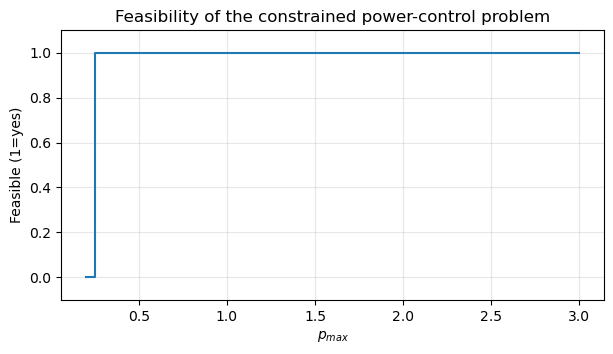

In [4]:
def check_power_feasibility(G, sigma, gamma, pmax):
    # Rebuild the linear inequalities for the chosen QoS target.
    A, u, _ = build_linear_power_model(G, sigma, gamma)
    # Only feasibility matters here, so a zero objective is sufficient.
    p = cp.Variable(G.shape[0], nonneg=True)
    problem = cp.Problem(cp.Minimize(0), [A @ p >= u, p <= pmax])
    safe_solve(problem)
    feasible = problem.status in {"optimal", "optimal_inaccurate"}
    return feasible, None if p.value is None else p.value


# Test a broad range of candidate power limits.
pmax_grid = np.linspace(0.2, 3.0, 29)
feasibility_records = []
for pmax in pmax_grid:
    feasible, _ = check_power_feasibility(G, sigma, gamma, pmax=pmax)
    feasibility_records.append({"pmax": pmax, "feasible": feasible})

# Convert the sweep into a table and extract the threshold of feasibility.
feasibility_df = pd.DataFrame(feasibility_records)
min_feasible_pmax = feasibility_df.loc[feasibility_df["feasible"], "pmax"].min()
display(feasibility_df.head())
print("Smallest tested feasible pmax:", min_feasible_pmax)

# Report one feasible and one infeasible example from the tested range.
feasible_case = float(min_feasible_pmax)
infeasible_case = float(feasibility_df.loc[~feasibility_df["feasible"], "pmax"].max())
print("Example feasible pmax:", feasible_case)
print("Example infeasible pmax:", infeasible_case)

# Plot feasibility as a binary step function over the tested limits.
plt.figure(figsize=(7, 3.5))
plt.step(feasibility_df["pmax"], feasibility_df["feasible"].astype(int), where="mid")
plt.ylim(-0.1, 1.1)
plt.xlabel("$p_{max}$")
plt.ylabel("Feasible (1=yes)")
plt.title("Feasibility of the constrained power-control problem")
plt.grid(True, alpha=0.3)
plt.show()


## Task 4: Uniform QoS scaling

The QoS target vector is replaced by `alpha * gamma`, and we estimate the largest value
of `alpha` that still permits a feasible solution under the fixed bound `p_i <= 2`.


/Users/dartmann/opt/anaconda3/lib/python3.9/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Estimated maximal alpha: 1.8164497224788647
Power allocation at maximal alpha estimate: [1.7713 1.4867 2.     1.6396]


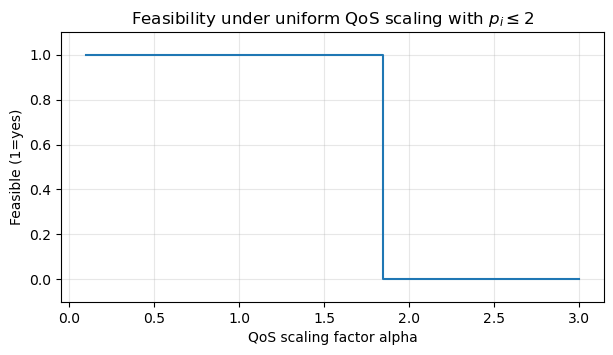

In [5]:
def is_feasible_for_alpha(alpha, pmax=2.0):
    # Reuse the same feasibility routine with a scaled target vector.
    return check_power_feasibility(G, sigma, alpha * gamma, pmax=pmax)


# Initialize the bisection search interval for alpha.
lower, upper = 0.0, 3.0
best_alpha = 0.0
best_power = None

for _ in range(35):
    # Test the midpoint of the current interval.
    # TODO: Compute the midpoint for the bisection step.
    midpoint = ...
    feasible, candidate_power = is_feasible_for_alpha(midpoint)
    if feasible:
        # Store the current best feasible value and search higher.
        best_alpha = midpoint
        best_power = candidate_power
        lower = midpoint
    else:
        # Shrink the interval from above when the target is too demanding.
        upper = midpoint

# Also evaluate feasibility on a grid so the result can be visualized.
alpha_grid = np.linspace(0.1, 3.0, 40)
alpha_feasible = [is_feasible_for_alpha(alpha)[0] for alpha in alpha_grid]

print("Estimated maximal alpha:", best_alpha)
print("Power allocation at maximal alpha estimate:", best_power)

# Plot the feasible and infeasible regions for the scaled QoS targets.
plt.figure(figsize=(7, 3.5))
plt.step(alpha_grid, np.array(alpha_feasible, dtype=int), where="mid")
plt.ylim(-0.1, 1.1)
plt.xlabel("QoS scaling factor alpha")
plt.ylabel("Feasible (1=yes)")
plt.title(r"Feasibility under uniform QoS scaling with $p_i \leq 2$")
plt.grid(True, alpha=0.3)
plt.show()


## Task 5: Random instance generator

The final task packages the model into a generator-driven experiment so several random
wireless networks can be solved with little manual effort.


In [6]:
def random_instance(n=4, seed=None):
    # Use a local generator so the function is deterministic for a given seed.
    local_rng = np.random.default_rng(seed)
    # Sample small off-diagonal entries for interference links.
    G = local_rng.uniform(0.03, 0.25, size=(n, n))
    # Replace the diagonal by larger direct-link gains.
    np.fill_diagonal(G, local_rng.uniform(0.8, 1.5, size=n))
    # Sample positive noise levels.
    sigma = local_rng.uniform(0.05, 0.2, size=n)
    # Sample positive SINR requirements.
    gamma = local_rng.uniform(0.6, 1.4, size=n)
    return G, sigma, gamma


# Solve five reproducible random instances under the power limit p_i <= 2.
experiment_rows = []
for instance_id in range(1, 6):
    G_i, sigma_i, gamma_i = random_instance(seed=100 + instance_id)
    instance_problem, instance_p = solve_power_control(G_i, sigma_i, gamma_i, pmax=2.0)
    feasible = instance_problem.status in {"optimal", "optimal_inaccurate"}
    # Count how many users hit the upper power bound when the instance is feasible.
    active_upper_bounds = (
        int(np.sum(np.isclose(instance_p.value, 2.0, atol=1e-4))) if feasible else np.nan
    )
    experiment_rows.append(
        {
            "instance": instance_id,
            "feasible": feasible,
            "minimum_total_power": instance_problem.value if feasible else np.nan,
            "active_upper_bounds": active_upper_bounds,
        }
    )

# Display the experiment summary.
random_instances_df = pd.DataFrame(experiment_rows)
display(random_instances_df)


,instance,feasible,minimum_total_power,active_upper_bounds
0,1,True,0.747557,0
1,2,True,0.587038,0
2,3,True,0.393155,0
3,4,True,0.654635,0
4,5,True,0.661584,0
